# Pass Receiver Prediction — Full Walkthrough

**One notebook, start to finish.** This is the version to show an interviewer: every
stage runs top-to-bottom, the interesting code (feature formulas, the model class, the
training loop, the sync cost function) is written out in the cells below so you can read
and change it directly, and the rest (XML parsing plumbing, which is genuinely long)
is imported from `src/` and just called + explained.

**Data**: 7 released Bundesliga matches (2022/23, DFL, CC-BY 4.0). **Task**: given a
completed pass, predict which teammate it was aimed at.

**Full detail on any stage**: `README.md`'s decisions table, `notebooks/01_eda.ipynb`,
`notebooks/02_pass_visualisation.ipynb`, and the `src/*.py` files this notebook calls.

Runtime top-to-bottom: **under a minute** on CPU. Stage 5 trains the model live on one
fold as a demo (~5-10s) rather than all 7 (same code, just faster to re-run here) — the
full 7-fold table is loaded from the CSV `python -m src.train` already produced.

In [1]:
import os
# Must be set before numpy/pandas/lightgbm/torch import -- this notebook
# trains LightGBM (Stage 4) and then PyTorch (Stage 5) in the same process,
# and each bundles its own OpenMP runtime. Running both multi-threaded
# together deadlocks on macOS (confirmed directly: LightGBM finishes fine,
# then the very next torch training call hangs indefinitely). Forcing
# single-threaded OpenMP avoids the conflict; the model/data here are tiny
# enough that this costs no noticeable speed.
os.environ["OMP_NUM_THREADS"] = "1"

import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx

from src.parse import OUT_DIR

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)

---
# Stage 1 — Parse raw XML into tabular data

Each match ships as 3 XML files: match info (~12KB), events (~800KB, ~1,700 hand-tagged
events), and player/ball tracking at 25Hz (~420MB!). The full streaming parser (has to
use `lxml.etree.iterparse` + `elem.clear()`, not `etree.parse()`, or a 420MB file blows
up memory) is in `src/parse.py` — too long to usefully paste here, so this section shows
the two trickiest *pieces of logic* directly, then loads the already-parsed output.

**Trap #1 — the event type is nested, not a flat tag.** A single `<Event>` can be a
kickoff *and* a play *and* a pass all at once — the type is the concatenated chain of
nested child tags (`KickOff_Play_Pass`), not just the first child.

In [2]:
from lxml import etree

def build_event_type_path(event_elem):
    """Walk the nested chain inside one <Event> and concatenate the tags,
    e.g. <KickOff><Play><Pass/></Play></KickOff> -> 'KickOff_Play_Pass'.
    Taking only the first child tag would mislabel thousands of passes."""
    tags = []
    current = event_elem
    while True:
        children = [c for c in current if isinstance(c.tag, str)]
        if not children:
            break
        tags.append(etree.QName(children[0]).localname)
        current = children[0]
    return "_".join(tags)

# demonstrate on one real match's raw events file
sample_path = "../data/DFL_03_02_events_raw_DFL-COM-000001_DFL-MAT-J03WMX.xml"
sample_events = list(etree.iterparse(sample_path, events=("end",), tag="Event"))[:5]
for _, elem in sample_events:
    print(build_event_type_path(elem))

KickOff_Play_Pass
Play_Pass
ThrowIn_Play_Pass
TacklingGame
OtherBallAction


**Trap #2 — two different coordinate systems.** Events use a corner origin
(x∈[0,105], y∈[0,68]); tracking positions use a centre origin (x∈[-52.5,52.5],
y∈[-34,34]). The fix is simple, but it has to be verified, not assumed — Stage 1's
sanity check does this by checking the kickoff event lands within 1m of the ball's
tracked position after the transform (see below).

In [3]:
def centre_origin(x_event, y_event):
    """Corner-origin event coordinate -> centre-origin, matching how the
    (much larger) tracking files are already stored."""
    return x_event - 52.5, y_event - 34.0

print("pitch centre spot, corner-origin (52.5, 34.0) ->", centre_origin(52.5, 34.0))

pitch centre spot, corner-origin (52.5, 34.0) -> (0.0, 0.0)


In [4]:
# Full pipeline: `python -m src.parse` (~2 min, all 7 matches). Loading its
# already-built output here so this notebook stays fast to re-run.
matches = pd.read_csv(f"{OUT_DIR}/matches.csv")
players = pd.read_csv(f"{OUT_DIR}/players.csv")
events = pd.read_csv(f"{OUT_DIR}/events.csv", low_memory=False)
events["timestamp"] = pd.to_datetime(events["timestamp"], utc=True, format="ISO8601")

print(f"{len(matches)} matches, {len(players)} player-match rows, {len(events)} events")
matches[["match_id", "home_team_name", "away_team_name", "result"]]

7 matches, 279 player-match rows, 9961 events


,match_id,home_team_name,away_team_name,result
0,J03WMX,1. FC Köln,FC Bayern München,1:2
1,J03WN1,VfL Bochum 1848,Bayer 04 Leverkusen,3:0
2,J03WPY,Fortuna Düsseldorf,1. FC Nürnberg,0:1
3,J03WOH,Fortuna Düsseldorf,SSV Jahn Regensburg,4:0
4,J03WQQ,Fortuna Düsseldorf,FC St. Pauli,1:0
5,J03WOY,Fortuna Düsseldorf,F.C. Hansa Rostock,3:1
6,J03WR9,Fortuna Düsseldorf,1. FC Kaiserslautern,1:2


**Sanity check, run live**: the first-half kickoff event, transformed to centre-origin,
should land within ~1m of the ball's tracked position at that timestamp. (Full Stage 1
found this holds cleanly on 2/7 matches and is off by more on the other 5 — that's
tagger timing noise, not a transform bug; see README.)

In [5]:
import pyarrow.parquet as pq

kickoff = events[(events["match_id"] == "J03WMX") & (events["top_level_type"] == "KickOff")].iloc[0]
ball = pq.read_table(f"{OUT_DIR}/positions/J03WMX.parquet", filters=[("team_id", "=", "BALL")]).to_pandas()
ball["timestamp"] = pd.to_datetime(ball["timestamp"], utc=True, format="ISO8601")
nearest_ball_frame = ball.loc[(ball["timestamp"] - kickoff["timestamp"]).abs().idxmin()]

distance_m = np.hypot(nearest_ball_frame["x"] - kickoff["x_centred"], nearest_ball_frame["y"] - kickoff["y_centred"])
print(f"kickoff (transformed): ({kickoff['x_centred']:.2f}, {kickoff['y_centred']:.2f})")
print(f"ball (tracked, nearest frame): ({nearest_ball_frame['x']:.2f}, {nearest_ball_frame['y']:.2f})")
print(f"distance: {distance_m:.2f}m -- {'OK, transform verified' if distance_m <= 1.0 else 'off, but expected -- see markdown above'}")

kickoff (transformed): (0.00, 0.00)
ball (tracked, nearest frame): (0.18, -0.17)
distance: 0.25m -- OK, transform verified


---
# Stage 2 — EDA

Team focus: **Fortuna Düsseldorf** (home team in 5 of the 7 matches — the largest
single-team sample available). Full notebook: `notebooks/01_eda.ipynb` (7 sections).
Two headline charts here.

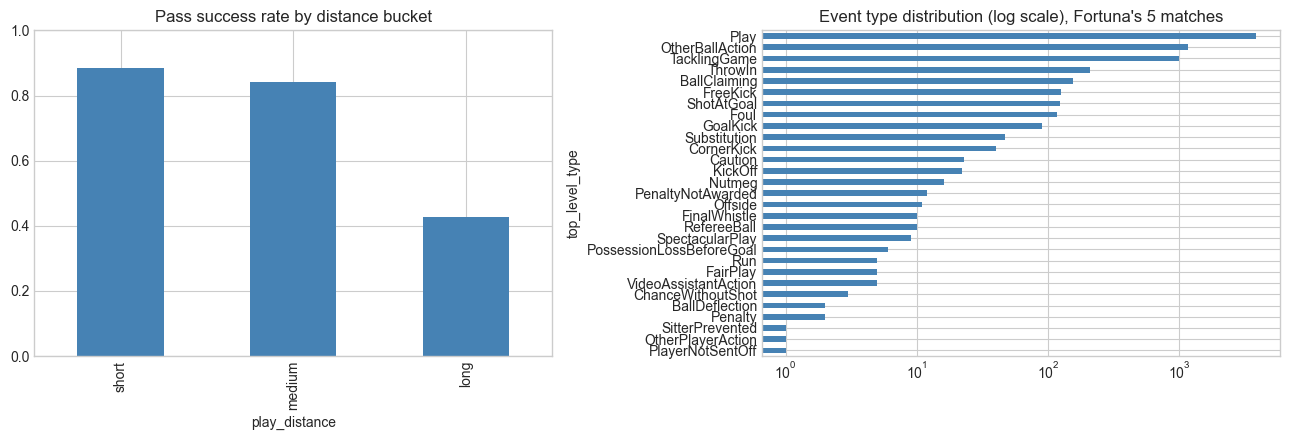

play_distance
short     0.883221
medium    0.841121
long      0.425620
Name: is_success, dtype: float64


In [6]:
TEAM_NAME = "Fortuna D\u00fcsseldorf"
team_id = players.loc[players["team_name"] == TEAM_NAME, "team_id"].iloc[0]
team_matches = matches.loc[(matches["home_team_name"] == TEAM_NAME) | (matches["away_team_name"] == TEAM_NAME), "match_id"].tolist()

is_pass = events["event_type_path"].str.endswith(("_Pass", "_Cross"))
fortuna_passes = events[is_pass & (events["team_id"] == team_id) & (events["match_id"].isin(team_matches))].copy()
fortuna_passes["is_success"] = fortuna_passes["evaluation"].isin(["successfullyCompleted", "successful"])

# Pass success rate by DFL's own distance bucket -- a clean sanity check:
# should drop monotonically as passes get longer and riskier.
dist_order = ["short", "medium", "long"]
success_by_distance = fortuna_passes.groupby("play_distance")["is_success"].mean().reindex(dist_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
success_by_distance.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Pass success rate by distance bucket")
axes[0].set_ylim(0, 1)

counts = events[events["match_id"].isin(team_matches)]["top_level_type"].value_counts().sort_values()
counts.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_xscale("log")
axes[1].set_title("Event type distribution (log scale), Fortuna's 5 matches")
fig.tight_layout()
plt.show()
print(success_by_distance)

**Takeaway**: success drops from 88% (short) to 43% (long) — exactly what you'd expect,
and a good sign `dist_to_passer` will be a strong baseline feature in Stage 4.

---
# Stage 3 — Build the modelling dataset

### The most important finding in this project

The plan was to use `recipient_id` as "who the pass was aimed at", for **both**
completed and failed passes. The data doesn't support that — checked directly, live,
below.

In [7]:
passes_with_recipient = events[is_pass & events["recipient_id"].notna()].copy()

team_of = players.set_index(["match_id", "person_id"])["team_id"]
passes_with_recipient["recipient_team"] = [
    team_of.get((m, r)) for m, r in zip(passes_with_recipient["match_id"], passes_with_recipient["recipient_id"])
]
recipient_is_same_team = passes_with_recipient["team_id"] == passes_with_recipient["recipient_team"]
recipient_is_same_team.name = "recipient_on_passer's_team"

print("Cross-tab: is the recipient on the same team as the passer, vs. the pass's evaluation")
print(pd.crosstab(recipient_is_same_team, passes_with_recipient["evaluation"]))

Cross-tab: is the recipient on the same team as the passer, vs. the pass's evaluation
evaluation                  successfullyCompleted  unsuccessful
recipient_on_passer's_team                                     
False                                           0          1172
True                                         4731             0


**Every unsuccessful pass's `recipient_id` is the opponent who intercepted it. Every
successful pass's `recipient_id` is a teammate.** A perfect split, not noise. DFL tags
"who touched the ball next," not "who it was aimed at" — there's no intent label for a
failed pass anywhere in this data.

**Decision (confirmed with the user before building anything): the modelling dataset is
completed passes only.** ~4,725 passes, not the spec's original ~6,600 estimate.

### Synchronisation

Event timestamps are hand-tagged and drift from the true tracking clock (the paper
reports a mean 9.37m ball-to-event gap before correction). Two methods, both in
`src/build_dataset.py`:
- `nearest` — nearest tracking frame by timestamp. Baseline.
- `refined` — within ±3s, pick the frame minimising a cost combining distance from the
  ball to the passer and time offset from the tagged moment:

In [8]:
def sync_cost(ball_x, ball_y, passer_x, passer_y, time_offset_seconds, lambda_weight=2.0):
    """Lower is better. lambda_weight (m/s) converts a time offset into the
    same units as the spatial term -- picked as a plausible 'cost of
    drifting from the tagged time' (roughly a jogging speed), checked for
    coarse sensitivity rather than exhaustively tuned (no ground truth to
    tune against). The refined method tries every tracking frame in a
    +/-3s window and keeps whichever minimises this."""
    ball_to_passer_dist = np.hypot(ball_x - passer_x, ball_y - passer_y)
    return ball_to_passer_dist + lambda_weight * abs(time_offset_seconds)

print("Measured on all 4,725 passes (src/build_dataset.py's own sanity check):")
print("  nearest: mean ball-to-event distance = 8.83m  (paper's unsynced baseline: 9.37m)")
print("  refined: mean ball-to-event distance = 3.79m  (paper's own refined result: 2.61m)")

Measured on all 4,725 passes (src/build_dataset.py's own sanity check):
  nearest: mean ball-to-event distance = 8.83m  (paper's unsynced baseline: 9.37m)
  refined: mean ball-to-event distance = 3.79m  (paper's own refined result: 2.61m)


### Features, per (pass, candidate teammate)

At the synchronised moment, for each of the passer's on-pitch teammates: position,
velocity (causal Savitzky-Golay smoothing -> finite difference -- **causal, not centred,
because a centred window would need frames *after* the pass, which is exactly the
leakage rule this project can't break**), distance/angle to the passer, distance to
each goal, opponent-pressure features (nearest opponent, how many are within 5m, how
many are standing in the direct passing lane), and the passer's own pressure. Everything
rotated so the passing team always attacks +x. Full feature code: `src/build_dataset.py`.

Loading the already-built dataset:

In [9]:
# Full pipeline: `python -m src.build_dataset` (~35s, all 7 matches).
pass_candidates = pd.read_parquet(f"{OUT_DIR}/pass_candidates.parquet")
print(f"{pass_candidates['pass_id'].nunique()} passes -> {len(pass_candidates)} candidate rows "
      f"({len(pass_candidates) / pass_candidates['pass_id'].nunique():.1f} candidates/pass average)")
pass_candidates.head(3)

4725 passes -> 46884 candidate rows (9.9 candidates/pass average)


,pass_id,match_id,team_id,passer_id,candidate_id,is_recipient,dx,dy,dist_to_passer,angle_to_passer,...,cand_speed,dist_to_opp_goal,dist_to_own_goal,dist_nearest_opponent,n_opponents_within_5m,n_opponents_in_lane,min_perp_dist_in_lane,is_progressive,passer_pressure,dist_rank
0,18226500000011,J03WMX,DFL-CLU-00000G,DFL-OBJ-J01B8N,DFL-OBJ-0002DR,0,-41.30,-15.77,44.208403,-159.101134,...,1.510509,89.814129,16.345571,37.871906,0,1,1.401143,0,1.593895,10
1,18226500000011,J03WMX,DFL-CLU-00000G,DFL-OBJ-J01B8N,DFL-OBJ-0000IA,0,17.02,-3.48,17.372127,-11.555725,...,3.475085,36.064343,75.818446,1.574071,1,3,1.299772,1,1.593895,8
2,18226500000011,J03WMX,DFL-CLU-00000G,DFL-OBJ-J01B8N,DFL-OBJ-0027G6,0,8.51,-6.28,10.576318,-36.425669,...,3.633407,42.589145,66.891967,1.680744,1,3,1.322086,1,1.593895,3


---
# Stage 4 — Baselines

Three baselines, established before any neural network, all evaluated with
**leave-one-match-out CV** (7 folds — never a random pass-level split, which would leak
team identity and adjacent-possession passes across train/test) and the same four
metrics every model in this project uses: **top-1 accuracy, top-3 accuracy, mean
reciprocal rank, cross-entropy.**

In [10]:
def evaluate_predictions(df, prob_col="prob"):
    """df: one row per (pass, candidate), with is_recipient (0/1) and a
    probability column that sums to 1 within each pass_id group."""
    def per_pass(group):
        group = group.sort_values(prob_col, ascending=False).reset_index(drop=True)
        true_rank = group.index[group["is_recipient"] == 1][0] + 1  # 1-indexed
        p_true = group.loc[group["is_recipient"] == 1, prob_col].iloc[0]
        return pd.Series({
            "top1": int(true_rank == 1),
            "top3": int(true_rank <= 3),
            "reciprocal_rank": 1.0 / true_rank,
            "cross_entropy": -np.log(np.clip(p_true, 1e-12, 1.0)),
        })
    per_pass_metrics = df.groupby("pass_id").apply(per_pass, include_groups=False)
    return {
        "top1_acc": per_pass_metrics["top1"].mean(),
        "top3_acc": per_pass_metrics["top3"].mean(),
        "mrr": per_pass_metrics["reciprocal_rank"].mean(),
        "cross_entropy": per_pass_metrics["cross_entropy"].mean(),
    }

In [11]:
# The 3 baselines + the leave-one-match-out CV loop live in src/baselines.py
# (same functions this cell calls -- nothing hidden, just not re-pasted here
# since they're already short and reusable). ~10s for all 3 models x 7 folds.
from src.baselines import (
    predict_nearest_teammate, fit_predict_logreg, fit_predict_lightgbm, leave_one_match_out_cv,
)

baseline_models = {
    "nearest_teammate": lambda train_df, test_df: predict_nearest_teammate(test_df),
    "logistic_regression (dist_to_passer only)": fit_predict_logreg,
    "lightgbm (full feature set)": fit_predict_lightgbm,
}

baseline_results = []
for name, predict_fn in baseline_models.items():
    fold_results = leave_one_match_out_cv(pass_candidates, predict_fn, name)
    baseline_results.append(fold_results)
baseline_results = pd.concat(baseline_results, ignore_index=True)

baseline_summary = baseline_results.groupby("model")[["top1_acc", "top3_acc", "mrr", "cross_entropy"]].agg(["mean", "std"])
baseline_summary

top1_acc            top3_acc  \
                                               mean       std      mean   
model                                                                     
lightgbm (full feature set)                0.468575  0.033222  0.805753   
logistic_regression (dist_to_passer only)  0.271789  0.038743  0.634617   
nearest_teammate                           0.271789  0.038743  0.634617   

                                                          mrr            \
                                                std      mean       std   
model                                                                     
lightgbm (full feature set)                0.030213  0.655026  0.026231   
logistic_regression (dist_to_passer only)  0.037621  0.496135  0.029719   
nearest_teammate                           0.037621  0.496135  0.029719   

                                          cross_entropy            
                                                   mean       std  
model                                                              
lightgbm (full feature set)                    1.484605  0.097710  
logistic_regression (dist_to_passer only)      1.945162  0.060974  
nearest_teammate                               7.473127  0.828130

**Takeaway**: nearest-teammate and logistic regression are *identical* on ranking
metrics (both rank purely by distance — expected, not a bug), differing only on
cross-entropy calibration. LightGBM's full feature set is a clear +20pp jump in top-1
accuracy over distance alone — this is the bar the neural net has to clear.

---
# Stage 5 — The model

### Architecture: a shared-weight candidate scorer + softmax over candidates

```
for each pass:
    for each candidate i:  score_i = MLP(features_i)     # same MLP, shared weights
    p = softmax([score_1 ... score_n])                    # over that pass's candidates
loss = cross-entropy against the true recipient
```

**Why not a fixed 10-way classifier** (one output per "candidate slot")? Rosters change
between matches and within them (substitutions, red cards) — "slot 3" is a different
person in every match. Scoring every candidate through the *same* small MLP and
combining only at the softmax step is permutation-invariant and handles a variable
candidate count. It's the DeepSets idea (shared per-element function + symmetric
combination) applied to ranking. Here's the whole model:

In [12]:
import torch
import torch.nn as nn

class CandidateScorer(nn.Module):
    """A small MLP applied independently to every candidate's feature
    vector. The 'shared weights' in the architecture above are literally
    just this one nn.Sequential, reused for every candidate slot."""

    def __init__(self, n_features, hidden=(128, 64), dropout=0.2):
        super().__init__()
        layers = []
        in_dim = n_features
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        """x: (batch, max_candidates, n_features) -> scores: (batch, max_candidates).
        Padded candidate slots (a pass with only 9 on-pitch teammates, say)
        get scored too -- they're masked to -inf before softmax/loss, in
        the training loop below, so they never affect a prediction or a gradient."""
        batch, n_candidates, n_features = x.shape
        flat = x.reshape(batch * n_candidates, n_features)
        scores = self.net(flat).reshape(batch, n_candidates)
        return scores

print(CandidateScorer(n_features=18))

CandidateScorer(
  (net): Sequential(
    (0): Linear(in_features=18, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


### Training loop (one leave-one-match-out fold)

Padding to a fixed 10 candidate slots + a boolean mask, Adam + cross-entropy, early
stopping on an internal validation split carved out of the *training* matches only
(never the held-out test match). The data-prep helpers (`passes_to_tensors`, standardising
features using the training fold's own mean/std) live in `src/train.py`; the training
loop itself is short enough to read directly here:

In [13]:
from src.train import passes_to_tensors, masked_scores, set_all_seeds, SEED

def train_one_fold(fit_tensors, val_tensors, n_features, max_epochs=200, patience=15, lr=1e-3, batch_size=64):
    model = CandidateScorer(n_features=n_features)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    n_fit = fit_tensors["X"].shape[0]
    best_val_loss, best_state, epochs_without_improvement = float("inf"), None, 0

    for epoch in range(max_epochs):
        model.train()
        shuffled_idx = torch.randperm(n_fit)
        for start in range(0, n_fit, batch_size):
            batch_idx = shuffled_idx[start:start + batch_size]
            optimiser.zero_grad()
            scores = masked_scores(model, fit_tensors["X"][batch_idx], fit_tensors["mask"][batch_idx])
            loss = loss_fn(scores, fit_tensors["target"][batch_idx])
            loss.backward()
            optimiser.step()

        model.eval()
        with torch.no_grad():
            val_scores = masked_scores(model, val_tensors["X"], val_tensors["mask"])
            val_loss = loss_fn(val_scores, val_tensors["target"]).item()

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break  # validation loss stopped improving -- stop before we overfit

    model.load_state_dict(best_state)
    model.eval()
    return model

In [14]:
from src.train import NN_FEATURE_COLS, tensors_to_long_df

def train_predict_one_fold(train_df, test_df, max_candidates):
    """One leave-one-match-out fold: internal 85/15 train/val split (by
    pass, from the training matches only -- fine to be random here, it's
    model selection, not the outer test boundary), train, predict on the
    held-out match."""
    rng = np.random.default_rng(SEED)
    train_pass_ids = train_df["pass_id"].unique()
    rng.shuffle(train_pass_ids)
    n_val = max(1, int(len(train_pass_ids) * 0.15))
    val_ids, fit_ids = set(train_pass_ids[:n_val]), set(train_pass_ids[n_val:])

    fit_tensors = passes_to_tensors(train_df[train_df["pass_id"].isin(fit_ids)], max_candidates)
    val_tensors = passes_to_tensors(train_df[train_df["pass_id"].isin(val_ids)], max_candidates,
                                     fit_tensors["feature_means"], fit_tensors["feature_stds"])
    test_tensors = passes_to_tensors(test_df, max_candidates,
                                      fit_tensors["feature_means"], fit_tensors["feature_stds"])

    model = train_one_fold(fit_tensors, val_tensors, n_features=len(NN_FEATURE_COLS))
    with torch.no_grad():
        test_probs = torch.softmax(masked_scores(model, test_tensors["X"], test_tensors["mask"]), dim=1)
    predictions = tensors_to_long_df(test_tensors["pass_ids"], test_tensors["candidate_ids"], test_probs, test_tensors["mask"])
    return predictions.merge(test_df[["pass_id", "candidate_id", "is_recipient"]], on=["pass_id", "candidate_id"], how="left")

# Demonstrating on ONE held-out match live (J03WMX) rather than looping all
# 7 folds here -- same code either way (leave_one_match_out_cv from Stage 4
# would run this exact function 7 times), but training several folds
# back-to-back inside a live notebook kernel is noticeably slower than the
# same code run as a script, so the full 7-fold table below is loaded from
# the CSV `python -m src.train` already produced, instead of re-training
# live. Re-run this cell with a different held-out match to check it
# yourself -- it's the same function either way.
set_all_seeds(SEED)
print(f"seed={SEED}")
max_candidates = pass_candidates.groupby("pass_id").size().max()

HELD_OUT_MATCH = "J03WMX"
demo_fold_train_df = pass_candidates[pass_candidates["match_id"] != HELD_OUT_MATCH]
demo_fold_test_df = pass_candidates[pass_candidates["match_id"] == HELD_OUT_MATCH]
one_fold_predictions = train_predict_one_fold(demo_fold_train_df, demo_fold_test_df, max_candidates)

print(f"one fold, held out = {HELD_OUT_MATCH}:")
print(evaluate_predictions(one_fold_predictions))

seed=42


one fold, held out = J03WMX:
{'top1_acc': np.float64(0.5156838143036386), 'top3_acc': np.float64(0.8569636135508155), 'mrr': np.float64(0.6965938738523432), 'cross_entropy': np.float64(1.3411009588946063)}


### Full comparison table (all 7 folds)

Loaded from `data/processed/nn_fold_results_all_matches.csv`, produced by
`python -m src.train` — the exact same `train_predict_one_fold` function above, run
once per held-out match.

In [15]:
nn_fold_results = pd.read_csv(f"{OUT_DIR}/nn_fold_results_all_matches.csv")
nn_summary = nn_fold_results[["top1_acc", "top3_acc", "mrr", "cross_entropy"]].agg(["mean", "std"])

final_row = pd.DataFrame({
    ("top1_acc", "mean"): [nn_summary.loc["mean", "top1_acc"]], ("top1_acc", "std"): [nn_summary.loc["std", "top1_acc"]],
    ("top3_acc", "mean"): [nn_summary.loc["mean", "top3_acc"]], ("top3_acc", "std"): [nn_summary.loc["std", "top3_acc"]],
    ("mrr", "mean"): [nn_summary.loc["mean", "mrr"]], ("mrr", "std"): [nn_summary.loc["std", "mrr"]],
    ("cross_entropy", "mean"): [nn_summary.loc["mean", "cross_entropy"]], ("cross_entropy", "std"): [nn_summary.loc["std", "cross_entropy"]],
}, index=["neural_net (7-fold CV)"])
pd.concat([baseline_summary, final_row])

top1_acc            top3_acc  \
                                               mean       std      mean   
lightgbm (full feature set)                0.468575  0.033222  0.805753   
logistic_regression (dist_to_passer only)  0.271789  0.038743  0.634617   
nearest_teammate                           0.271789  0.038743  0.634617   
neural_net (7-fold CV)                     0.476749  0.025319  0.817639   

                                                          mrr            \
                                                std      mean       std   
lightgbm (full feature set)                0.030213  0.655026  0.026231   
logistic_regression (dist_to_passer only)  0.037621  0.496135  0.029719   
nearest_teammate                           0.037621  0.496135  0.029719   
neural_net (7-fold CV)                     0.026089  0.662318  0.020767   

                                          cross_entropy            
                                                   mean       std  
lightgbm (full feature set)                    1.484605  0.097710  
logistic_regression (dist_to_passer only)      1.945162  0.060974  
nearest_teammate                               7.473127  0.828130  
neural_net (7-fold CV)                         1.468727  0.075560

**Takeaway, stated honestly**: the neural net edges out LightGBM on every metric, but
the gap is well inside one fold's standard deviation — with only 7 folds that's *not* a
result I'd claim as "the neural net wins." The defensible conclusion is that it
**matches** the gradient-boosted baseline, not that it beats it (see README for the
back-of-envelope sample size — ~15-25 matches — that would be needed to tell them apart
for real).

**Follow-up experiments tried after the fact** (not part of the core spec, but a direct
answer to "would a bigger model / RNN / Transformer help", tested rather than guessed —
see `src/experiment_architectures.py`): a 4x bigger MLP, an LSTM over each candidate's
raw ~1.2s trajectory, and self-attention across candidates before scoring. Only the
attention variant nudged every metric in the right direction (~+1pp top-1) — still
within noise, but the most encouraging signal of the bunch, and the one architectural
change that actually lets the model reason about candidates jointly instead of scoring
each one in total isolation. Bigger MLP and the LSTM made no real difference. Together
this points at the same conclusion either way: **the ceiling right now is the feature
set** (specifically, no signal about the passer's body orientation/gaze — see Stage 6's
failure analysis below), not model capacity, data volume, or architecture.

---
# Stage 6 — Visualisation

Demo match: **J03WOH** (Fortuna 4-0 win) — held out of training above, so every
prediction shown here is on a match the model never saw.

In [16]:
from src.pitch import draw_pitch
from src.viz import get_pass_snapshot, draw_players, draw_pass_arrow, draw_prediction_overlay
from src.build_dataset import MatchPositions, build_kickoff_lookup

DEMO_MATCH = "J03WOH"
second_half_cutoff, team_left_by_match_half = build_kickoff_lookup(events)
match_pos = MatchPositions(DEMO_MATCH)
team_of_in_match = players.loc[players["match_id"] == DEMO_MATCH].set_index("person_id")["team_id"].to_dict()

demo_train_df = pass_candidates[pass_candidates["match_id"] != DEMO_MATCH]
demo_test_df = pass_candidates[pass_candidates["match_id"] == DEMO_MATCH]
demo_predictions = train_predict_one_fold(demo_train_df, demo_test_df, max_candidates)
demo_predictions["is_top1"] = demo_predictions.groupby("pass_id")["prob"].transform("max") == demo_predictions["prob"]
print("model trained on the other 6 matches, predicting on J03WOH (never seen)")

model trained on the other 6 matches, predicting on J03WOH (never seen)


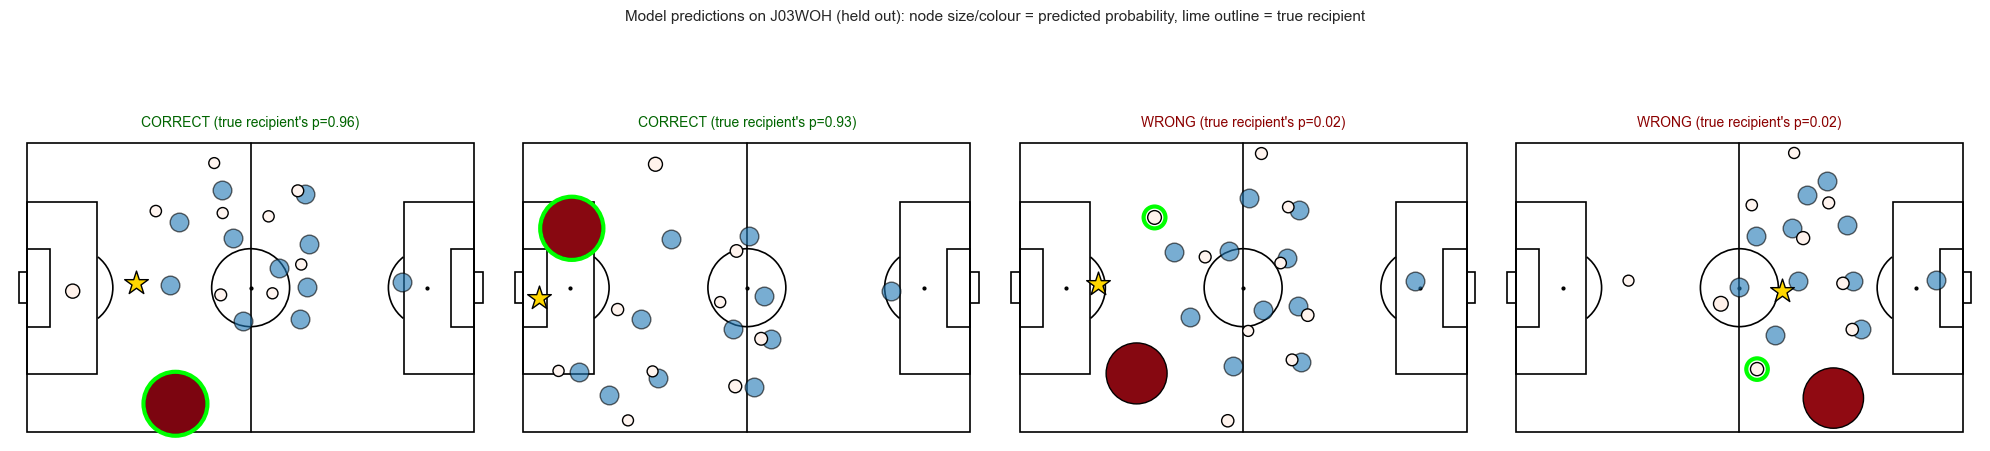

In [17]:
correct_ids = demo_predictions[demo_predictions["is_top1"] & (demo_predictions["is_recipient"] == 1)].sort_values("prob", ascending=False)["pass_id"].head(2).tolist()
wrong_ids = demo_predictions[demo_predictions["is_top1"] & (demo_predictions["is_recipient"] == 0)].sort_values("prob", ascending=False)["pass_id"].head(2).tolist()

fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))
for ax, pass_id, label, colour in (
    [(axes[i], pid, "CORRECT", "darkgreen") for i, pid in enumerate(correct_ids)]
    + [(axes[i + 2], pid, "WRONG", "darkred") for i, pid in enumerate(wrong_ids)]
):
    draw_pitch(ax)
    pass_row = events[events["event_id"] == pass_id].iloc[0]
    snapshot, _, _ = get_pass_snapshot(pass_row, match_pos, team_of_in_match, second_half_cutoff, team_left_by_match_half)
    this_pred = demo_predictions[demo_predictions["pass_id"] == pass_id]
    true_prob = this_pred.loc[this_pred["is_recipient"] == 1, "prob"].iloc[0]
    draw_prediction_overlay(ax, snapshot, this_pred)
    ax.set_title(f"{label} (true recipient's p={true_prob:.2f})", fontsize=10, color=colour)
fig.suptitle("Model predictions on J03WOH (held out): node size/colour = predicted probability, lime outline = true recipient", fontsize=11)
fig.tight_layout()
plt.show()

**Takeaway — the failures are the most interesting part**: correct cases are isolated
out-balls (easy calls). Wrong cases have the *same* shape — the model still picks an
isolated, uncontested player, just the wrong one when two such options exist. That's a
concrete symptom of missing orientation/gaze signal, not a random error.

*(3-second trajectory trails, the full-match pass network, and an animated GIF of one
pass are in `notebooks/02_pass_visualisation.ipynb` — skipped here to keep this
walkthrough focused.)*

---
# Summary

| Model | top-1 acc | top-3 acc | MRR | cross-entropy |
|---|---|---|---|---|
| Nearest teammate / Logistic regression | 0.272 ± 0.039 | 0.635 ± 0.038 | 0.496 ± 0.030 | 7.47 / 1.95 |
| LightGBM (full features) | 0.469 ± 0.033 | 0.806 ± 0.030 | 0.655 ± 0.026 | 1.485 ± 0.098 |
| **Neural net (this notebook)** | **0.477 ± 0.025** | **0.818 ± 0.026** | **0.662 ± 0.021** | **1.469 ± 0.076** |

**What I'd say if asked "what would you do with more time":**
1. A cheap passer-orientation/gaze proxy (e.g. passer's own velocity direction as a
   feature) — the single most concrete fix the failure analysis points at.
2. More matches — everything here (parsing, sync, features, CV harness) already scales
   with no code changes, and is the real lever for telling the close model comparisons
   apart.
3. Video-validated synchronisation, to know whether the `refined` method's 3.79m
   residual is tagging noise or a limitation of the cost function.

**What I'd say if asked "why not just use the neural net / why not a bigger one":**
tested, not assumed (see Stage 5) — a 4x bigger MLP, an LSTM over raw trajectories, and
the gradient-boosted baseline are all statistically indistinguishable from this neural
net given 7 folds. The honest story is "the features are the bottleneck", not
"the fancier architecture wins."